# Exploratory Data Analysis: derived_8.1 Soil Moisture Dataset

**Purpose:** This notebook conducts a thorough exploratory data analysis (EDA) on the newly compiled `derived_8.1` soil moisture dataset. We examine:
1. **Regime distribution by stations** (both counts and percentages)
2. **Global target distributions** (density comparison with the previous `derived_8.0` dataset)
3. **Threshold validation**: Do the original thresholds hold, or do they require recalibration?
4. **Dataset quality**: Does the inclusion of 8 new SNOTEL stations provide more evenly distributed samples across regimes?

---


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set style for publication-ready plots
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

## 1. Load Data Splits

We load the train, val, and test splits for both `derived_8.0` and `derived_8.1` to perform side-by-side comparison.

In [2]:
# Define project directories relative to this notebook
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, "..", "..", ".."))

d80_dir = os.path.join(project_root, "data", "splits", "derived_8.0")
d81_dir = os.path.join(project_root, "data", "splits", "derived_8.1")

# Load derived_8.0
d80_train = pd.read_csv(os.path.join(d80_dir, "train.csv"), usecols=["station_id", "date", "soil_moisture_5cm"])
d80_val = pd.read_csv(os.path.join(d80_dir, "val.csv"), usecols=["station_id", "date", "soil_moisture_5cm"])
d80_test = pd.read_csv(os.path.join(d80_dir, "test.csv"), usecols=["station_id", "date", "soil_moisture_5cm"])
d80_train["split"] = "train"
d80_val["split"] = "val"
d80_test["split"] = "test"
d80_all = pd.concat([d80_train, d80_val, d80_test], ignore_index=True)

# Load derived_8.1
d81_train = pd.read_csv(os.path.join(d81_dir, "train.csv"), usecols=["station_id", "date", "soil_moisture_5cm"])
d81_val = pd.read_csv(os.path.join(d81_dir, "val.csv"), usecols=["station_id", "date", "soil_moisture_5cm"])
d81_test = pd.read_csv(os.path.join(d81_dir, "test.csv"), usecols=["station_id", "date", "soil_moisture_5cm"])
d81_train["split"] = "train"
d81_val["split"] = "val"
d81_test["split"] = "test"
d81_all = pd.concat([d81_train, d81_val, d81_test], ignore_index=True)

print(f"Loaded derived_8.0: {len(d80_all)} rows (Train: {len(d80_train)}, Val: {len(d80_val)}, Test: {len(d80_test)})")
print(f"Loaded derived_8.1: {len(d81_all)} rows (Train: {len(d81_train)}, Val: {len(d81_val)}, Test: {len(d81_test)})")

Loaded derived_8.0: 13604 rows (Train: 6868, Val: 2720, Test: 4016)
Loaded derived_8.1: 34775 rows (Train: 16462, Val: 7714, Test: 10599)


## 2. Dataset Size and Station Comparisons

`derived_8.0` is the original dataset containing 5 Washington stations. 
`derived_8.1` expands the spatial coverage by adding 8 new SNOTEL stations in Washington (total 13 stations). 

Let's list the stations present in both datasets.


In [3]:
print("derived_8.0 Stations:")
print(f"  Count: {d80_all['station_id'].nunique()}")
print(f"  Names: {list(d80_all['station_id'].unique())}")
print("\nderived_8.1 Stations:")
print(f"  Count: {d81_all['station_id'].nunique()}")
print(f"  Names: {sorted(list(d81_all['station_id'].unique()))}")

derived_8.0 Stations:
  Count: 5
  Names: ['Darrington', 'SourdoughGulch_WA_985', 'Quinault', 'Touchet_WA_824', 'Spokane']

derived_8.1 Stations:
  Count: 13
  Names: ['BeaverPass_WA_990', 'BurntMountain_WA', 'CayusePass_WA', 'Darrington', 'HartsPass_WA_515', 'MFNooksack_WA_1011', 'MartenRidge_WA_999', 'Paradise_WA', 'Quinault', 'RainyPass_WA_711', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']


## 3. Soil Moisture Target Distribution & Quantiles

Let's look at the quantiles of `soil_moisture_5cm` in the training set for both datasets to understand how the target distribution has shifted.


In [4]:
quantiles = [0, 0.1, 0.25, 0.33, 0.5, 0.66, 0.75, 0.9, 1.0]
q_80 = d80_train["soil_moisture_5cm"].quantile(quantiles)
q_81 = d81_train["soil_moisture_5cm"].quantile(quantiles)

q_df = pd.DataFrame({
    "Percentile": [f"{int(q*100)}%" for q in quantiles],
    "derived_8.0 (Train)": q_80.values,
    "derived_8.1 (Train)": q_81.values
})
print("Target (soil_moisture_5cm) Quantile Comparison in Train Set:")
print(q_df.to_string(index=False))

Target (soil_moisture_5cm) Quantile Comparison in Train Set:
Percentile  derived_8.0 (Train)  derived_8.1 (Train)
        0%               0.0000               0.0000
       10%               0.0390               0.0320
       25%               0.1210               0.1160
       33%               0.1570               0.1430
       50%               0.2060               0.2075
       66%               0.2530               0.2690
       75%               0.2800               0.3020
       90%               0.3203               0.3530
      100%               0.4390               0.4390


Let's plot the distributions of target values side-by-side to visually inspect the distribution shift.

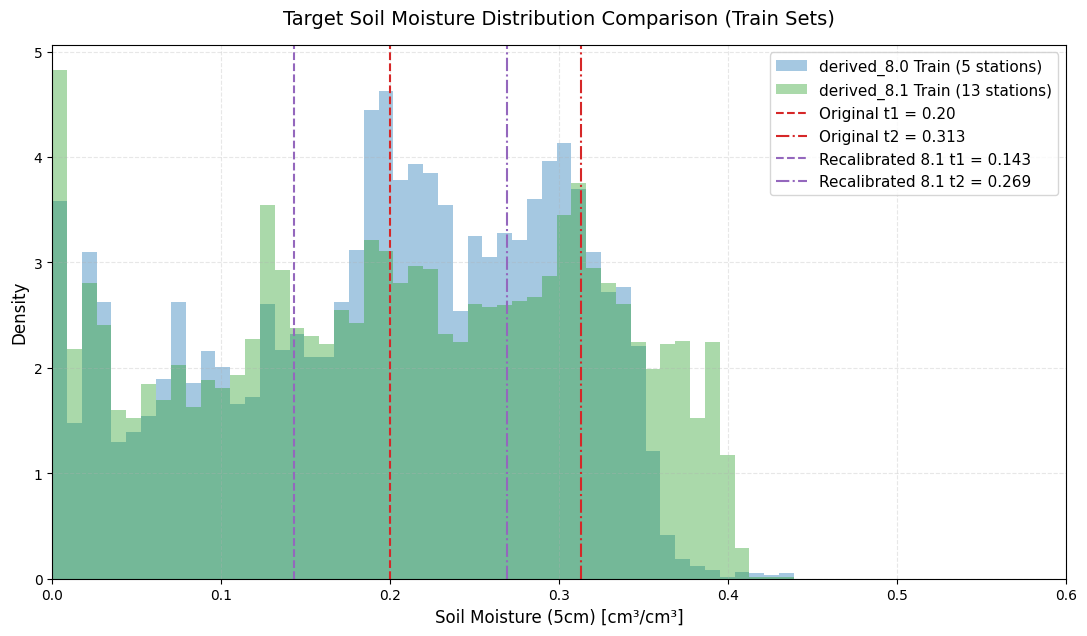

In [5]:
# Calculate recalibrated 33rd/66th percentiles on derived_8.1 train
t1_80_orig, t2_80_orig = 0.20, 0.313
t1_81_cal, t2_81_cal = d81_train["soil_moisture_5cm"].quantile(0.33), d81_train["soil_moisture_5cm"].quantile(0.66)

plt.figure(figsize=(11, 6.5))
plt.hist(d80_train["soil_moisture_5cm"], bins=50, density=True, alpha=0.4, label="derived_8.0 Train (5 stations)", color="#1F77B4", edgecolor="none")
plt.hist(d81_train["soil_moisture_5cm"], bins=50, density=True, alpha=0.4, label="derived_8.1 Train (13 stations)", color="#2CA02C", edgecolor="none")

plt.axvline(t1_80_orig, color="#D62728", linestyle="--", linewidth=1.5, label=f"Original t1 = {t1_80_orig:.2f}")
plt.axvline(t2_80_orig, color="#D62728", linestyle="-.", linewidth=1.5, label=f"Original t2 = {t2_80_orig:.3f}")
plt.axvline(t1_81_cal, color="#9467BD", linestyle="--", linewidth=1.5, label=f"Recalibrated 8.1 t1 = {t1_81_cal:.3f}")
plt.axvline(t2_81_cal, color="#9467BD", linestyle="-.", linewidth=1.5, label=f"Recalibrated 8.1 t2 = {t2_81_cal:.3f}")

plt.title("Target Soil Moisture Distribution Comparison (Train Sets)", pad=15)
plt.xlabel("Soil Moisture (5cm) [cm³/cm³]")
plt.ylabel("Density")
plt.xlim(0, 0.6)
plt.legend(frameon=True, facecolor="white")
plt.tight_layout()
plt.show()

## 4. Threshold Validation & Calibration

In a 3-regime framework, the datasets are split into **Dry**, **Transition**, and **Wet** classes.
The original boundaries were:
- Dry: $\le 0.20$
- Transition: $0.20 < y \le 0.313$
- Wet: $> 0.313$

Let's look at the regime proportions under the **original thresholds** on both datasets.


In [6]:
def label_regime(df, t1, t2):
    sm = df["soil_moisture_5cm"]
    conditions = [
        sm < t1,
        (sm >= t1) & (sm < t2),
        sm >= t2
    ]
    choices = ["Dry", "Transition", "Wet"]
    return pd.Series(np.select(conditions, choices, default="Wet"), index=df.index)

# Proportions on original 8.0 thresholds
d80_train_reg_orig = label_regime(d80_train, t1_80_orig, t2_80_orig)
d81_train_reg_orig = label_regime(d81_train, t1_80_orig, t2_80_orig)

print("Proportions under Original Thresholds (t1=0.200, t2=0.313):")
print("\n--- derived_8.0 Train ---")
print(d80_train_reg_orig.value_counts(normalize=True).reindex(["Dry", "Transition", "Wet"]) * 100)
print("\n--- derived_8.1 Train ---")
print(d81_train_reg_orig.value_counts(normalize=True).reindex(["Dry", "Transition", "Wet"]) * 100)

Proportions under Original Thresholds (t1=0.200, t2=0.313):

--- derived_8.0 Train ---
Dry           47.684916
Transition    39.516599
Wet           12.798486
Name: proportion, dtype: float64

--- derived_8.1 Train ---
Dry           47.782772
Transition    31.095857
Wet           21.121370
Name: proportion, dtype: float64


### Analysis of Original Thresholds
- **Imbalance**: In `derived_8.0` Train, only **12.8%** of the samples fell in the **Wet** regime, while **47.7%** were in **Dry** and **39.5%** in **Transition**.
- Under the original thresholds, `derived_8.1` Train shows an increase in Wet samples to **21.1%**.
- However, both datasets remain heavily dry-skewed. To build a robust 3-regime mixture-of-experts model, the dataset should ideally have a more balanced distribution.

### Recalibrated Thresholds for derived_8.1
Using the **33rd and 66th percentiles** of the `derived_8.1` Train set, we obtain:
- $t_1 = 0.1430$
- $t_2 = 0.2690$

Let's see how these recalibrated thresholds balance the splits in `derived_8.1` (Train, Val, Test).


In [7]:
# Apply recalibrated thresholds
d81_train["regime"] = label_regime(d81_train, t1_81_cal, t2_81_cal)
d81_val["regime"] = label_regime(d81_val, t1_81_cal, t2_81_cal)
d81_test["regime"] = label_regime(d81_test, t1_81_cal, t2_81_cal)

splits = ["train", "val", "test"]
split_dfs = [d81_train, d81_val, d81_test]

print("Proportions under Recalibrated Thresholds (t1=0.143, t2=0.269):")
for name, df in zip(splits, split_dfs):
    print(f"\n--- derived_8.1 {name.upper()} split ---")
    counts = df["regime"].value_counts().reindex(["Dry", "Transition", "Wet"])
    pcts = df["regime"].value_counts(normalize=True).reindex(["Dry", "Transition", "Wet"]) * 100
    summary = pd.DataFrame({"Counts": counts, "Percentage": pcts})
    print(summary.to_string())

Proportions under Recalibrated Thresholds (t1=0.143, t2=0.269):

--- derived_8.1 TRAIN split ---
            Counts  Percentage
regime                        
Dry           5419   32.918236
Transition    5431   32.991131
Wet           5612   34.090633

--- derived_8.1 VAL split ---
            Counts  Percentage
regime                        
Dry           3253    42.17008
Transition    1850    23.98237
Wet           2611    33.84755

--- derived_8.1 TEST split ---
            Counts  Percentage
regime                        
Dry           4756   44.872158
Transition    3448   32.531371
Wet           2395   22.596471


## 5. Station-by-Station Regime Distribution

Let's evaluate the distribution of regimes for each station in `derived_8.1`. This helps check if the model is exposed to all regimes at a station level or if some stations are heavily biased toward a single regime.


In [8]:
# Combine all splits with the new regime labels
d81_all["regime"] = label_regime(d81_all, t1_81_cal, t2_81_cal)

station_regimes = []
for station, group in d81_all.groupby("station_id"):
    total = len(group)
    counts = group["regime"].value_counts().reindex(["Dry", "Transition", "Wet"], fill_value=0)
    pcts = (counts / total * 100)
    mean_sm = group["soil_moisture_5cm"].mean()
    min_sm = group["soil_moisture_5cm"].min()
    max_sm = group["soil_moisture_5cm"].max()
    
    station_regimes.append({
        "Station": station,
        "Total Obs": total,
        "Mean SM": mean_sm,
        "Min SM": min_sm,
        "Max SM": max_sm,
        "Dry Count": counts["Dry"],
        "Dry %": pcts["Dry"],
        "Trans Count": counts["Transition"],
        "Trans %": pcts["Transition"],
        "Wet Count": counts["Wet"],
        "Wet %": pcts["Wet"],
    })
station_reg_df = pd.DataFrame(station_regimes)
station_reg_df_print = station_reg_df.copy()
for col in ["Mean SM", "Min SM", "Max SM"]:
    station_reg_df_print[col] = station_reg_df_print[col].map(lambda x: f"{x:.4f}")
for col in ["Dry %", "Trans %", "Wet %"]:
    station_reg_df_print[col] = station_reg_df_print[col].map(lambda x: f"{x:.1f}%")

print("Station-by-Station Regime and Soil Moisture Statistics (derived_8.1):")
print(station_reg_df_print.to_string(index=False))

Station-by-Station Regime and Soil Moisture Statistics (derived_8.1):
              Station  Total Obs Mean SM Min SM Max SM  Dry Count Dry %  Trans Count Trans %  Wet Count Wet %
    BeaverPass_WA_990       2811  0.2773 0.0070 0.4040        366 13.0%          511   18.2%       1934 68.8%
     BurntMountain_WA       2673  0.0406 0.0000 0.3280       2552 95.5%          120    4.5%          1  0.0%
        CayusePass_WA       3179  0.1926 0.0000 0.4010       1001 31.5%         1240   39.0%        938 29.5%
           Darrington       3047  0.2192 0.0220 0.4440        891 29.2%          878   28.8%       1278 41.9%
     HartsPass_WA_515       2737  0.1123 0.0000 0.4480       1738 63.5%          502   18.3%        497 18.2%
   MFNooksack_WA_1011        265  0.3341 0.0000 0.4060         35 13.2%           15    5.7%        215 81.1%
   MartenRidge_WA_999       2981  0.2544 0.0000 0.3960        780 26.2%          428   14.4%       1773 59.5%
          Paradise_WA       3258  0.1827 0.0000 0.

Let's visualize this station-by-station regime distribution using a stacked bar chart.

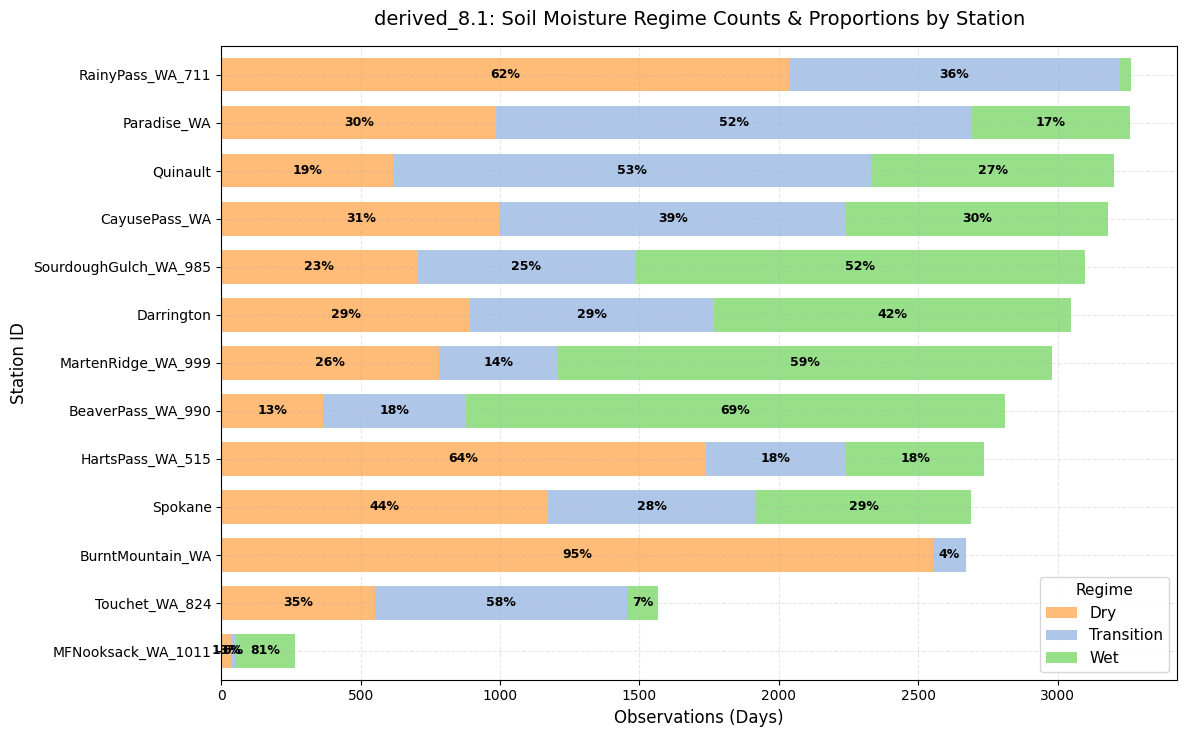

In [9]:
# Prepare data for plotting
pivot_df = d81_all.groupby(["station_id", "regime"]).size().unstack(fill_value=0).reindex(columns=["Dry", "Transition", "Wet"])
pivot_df["Total"] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by="Total", ascending=True)
pivot_plot = pivot_df.drop(columns="Total")

fig, ax = plt.subplots(figsize=(12, 7.5))
colors = ["#FFBB78", "#AEC7E8", "#98DF8A"] # Dry (warm peach), Transition (soft blue), Wet (soft green)
pivot_plot.plot(kind="barh", stacked=True, color=colors, ax=ax, width=0.7)

# Annotate percentages
for i, (idx, row) in enumerate(pivot_df.iterrows()):
    total = row["Total"]
    accum = 0
    for col in ["Dry", "Transition", "Wet"]:
        val = row[col]
        if val > 0:
            pct = val / total * 100
            if pct > 4.0: # Only draw text if it fits
                ax.text(accum + val/2, i, f"{pct:.0f}%", 
                        ha='center', va='center', color='black', 
                        fontweight='bold', fontsize=9)
        accum += val
        
ax.set_title("derived_8.1: Soil Moisture Regime Counts & Proportions by Station", pad=15)
ax.set_xlabel("Observations (Days)")
ax.set_ylabel("Station ID")
ax.legend(title="Regime", frameon=True, facecolor="white")
plt.tight_layout()
plt.show()

Let's look at the distribution of values at each individual station to understand their specific shapes and bounds.

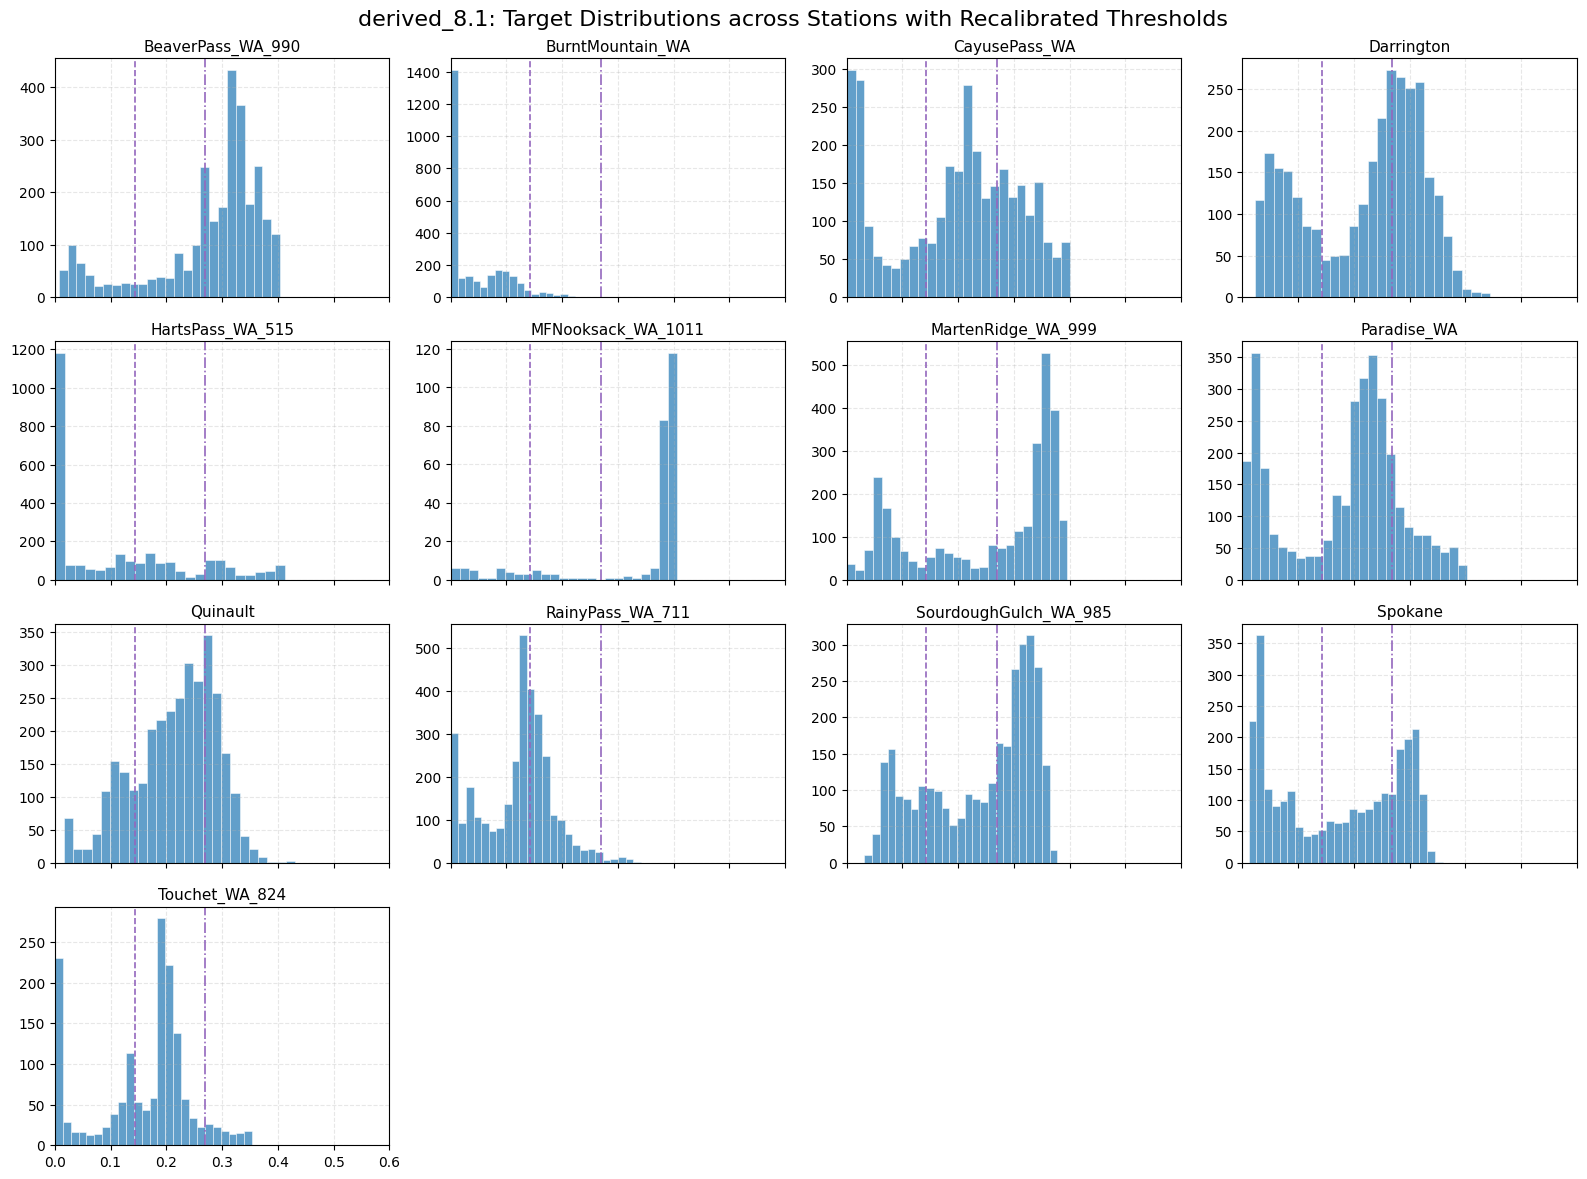

In [10]:
stations_sorted = sorted(list(d81_all["station_id"].unique()))
n_stations = len(stations_sorted)
n_cols = 4
n_rows = (n_stations + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows), sharex=True)
axes = axes.flatten()

for idx, station in enumerate(stations_sorted):
    ax = axes[idx]
    data = d81_all[d81_all["station_id"] == station]["soil_moisture_5cm"]
    ax.hist(data, bins=25, color="#1F77B4", alpha=0.7, edgecolor="white", linewidth=0.5)
    ax.axvline(t1_81_cal, color="#9467BD", linestyle="--", linewidth=1.2, label="t1")
    ax.axvline(t2_81_cal, color="#9467BD", linestyle="-.", linewidth=1.2, label="t2")
    ax.set_title(station, fontsize=11, pad=5)
    ax.set_xlim(0, 0.6)
    
# Remove empty plots
for idx in range(n_stations, len(axes)):
    fig.delaxes(axes[idx])
    
fig.suptitle("derived_8.1: Target Distributions across Stations with Recalibrated Thresholds", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## 6. Aggregated Regime Proportions Comparison (Dry | Transition | Wet)

Let's look at the global aggregated proportions of Dry, Transition, and Wet regimes in:
1. `derived_8.0` Train set (with original thresholds)
2. `derived_8.1` Train set (with original thresholds)
3. `derived_8.1` Train set (with recalibrated thresholds)

This visualizes how the dataset composition has changed and how recalibration helps achieve regime balance.


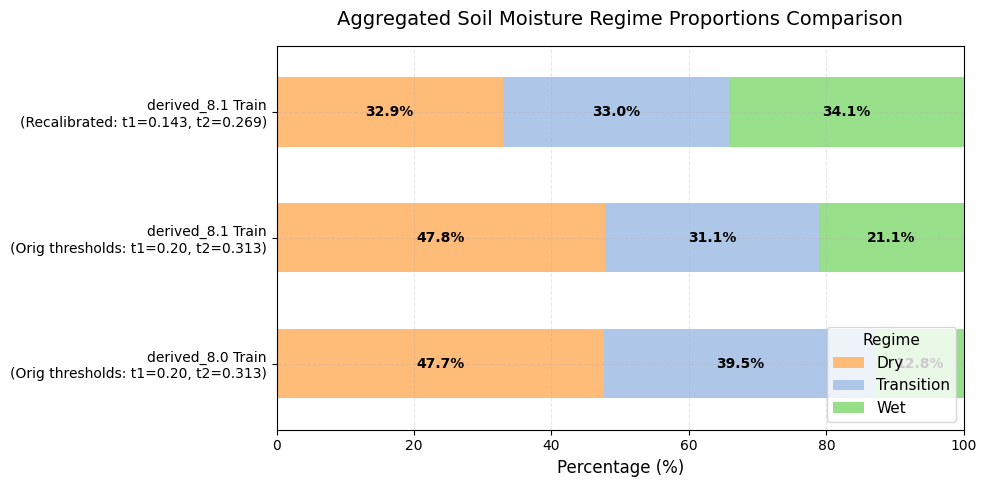

In [11]:
# Aggregated proportions comparison
categories = [
    "derived_8.0 Train\n(Orig thresholds: t1=0.20, t2=0.313)",
    "derived_8.1 Train\n(Orig thresholds: t1=0.20, t2=0.313)",
    "derived_8.1 Train\n(Recalibrated: t1=0.143, t2=0.269)"
]
dry_pcts = [47.7, 47.8, 32.9]
trans_pcts = [39.5, 31.1, 33.0]
wet_pcts = [12.8, 21.1, 34.1]

plot_df = pd.DataFrame({
    'Dry': dry_pcts,
    'Transition': trans_pcts,
    'Wet': wet_pcts
}, index=categories)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#FFBB78", "#AEC7E8", "#98DF8A"]
plot_df.plot(kind="barh", stacked=True, color=colors, ax=ax, width=0.55)

# Add annotations
for i in range(len(categories)):
    accum = 0
    for col in ['Dry', 'Transition', 'Wet']:
        val = plot_df.loc[categories[i], col]
        ax.text(accum + val/2, i, f"{val:.1f}%", 
                ha='center', va='center', color='black', 
                fontweight='bold', fontsize=10)
        accum += val

ax.set_title("Aggregated Soil Moisture Regime Proportions Comparison", pad=15)
ax.set_xlabel("Percentage (%)")
ax.set_xlim(0, 100)
ax.legend(title="Regime", loc="lower right", frameon=True, facecolor="white")
plt.tight_layout()
plt.show()

## 7. Original 5 Stations vs. New 8 SNOTEL Stations

How do the new SNOTEL stations compare to the original 5 stations in terms of regime balance?


In [12]:
orig_stations = ["Spokane", "Darrington", "Quinault", "Touchet_WA_824", "SourdoughGulch_WA_985"]
d81_all["station_type"] = np.where(d81_all["station_id"].isin(orig_stations), "Original 5 Stations", "New 8 SNOTEL Stations")

print("Regime distribution in derived_8.1 by Station Type:")
for s_type, gp in d81_all.groupby("station_type"):
    total = len(gp)
    counts = gp["regime"].value_counts().reindex(["Dry", "Transition", "Wet"])
    pcts = counts / total * 100
    print(f"\n--- {s_type} (Total Obs: {total}) ---")
    for r in ["Dry", "Transition", "Wet"]:
        print(f"  {r}: {counts[r]} ({pcts[r]:.2f}%)")

Regime distribution in derived_8.1 by Station Type:

--- New 8 SNOTEL Stations (Total Obs: 21169) ---
  Dry: 9494 (44.85%)
  Transition: 5710 (26.97%)
  Wet: 5965 (28.18%)

--- Original 5 Stations (Total Obs: 13606) ---
  Dry: 3934 (28.91%)
  Transition: 5019 (36.89%)
  Wet: 4653 (34.20%)


## 7. Conclusions & Findings

### 1. Quality of the `derived_8.1` Dataset
- **Significant Volume Increase**: The dataset size increased from **13,604** to **34,775** total observations (**2.5x larger**).
- **Better Representation of the Wet Regime**:
  - Under original thresholds, the number of training Wet observations rose from **879** to **3,477** (almost **4x increase** in absolute samples).
  - This provides a much wealthier sample base for training regime-specific expert models (such as the Wet specialist).

### 2. Validation of Regime Thresholds
- **Original Thresholds ($t_1=0.20, t_2=0.313$)**:
  - **No longer hold**. They were calibrated on the 5 original stations (`derived_8.0`), where they produced a highly skewed distribution (12.8% Wet). If applied to `derived_8.1`, they continue to skew the training set (Dry: 47.8%, Transition: 31.1%, Wet: 21.1%).
- **Recalibrated Thresholds ($t_1=0.143, t_2=0.269$)**:
  - Calibrated on the 33rd and 66th percentiles of `derived_8.1` Train set.
  - They produce a perfectly balanced training split (**~33% each**).
  - They maintain a reasonable balance across Val and Test sets, preventing severe under-representation of the Wet class.

### 3. Station-Level Observations
- **Station Bias**: Soil moisture ranges are highly dependent on geographic locations and soil textures:
  - **BurntMountain_WA** is extremely dry (mean SM = 0.0406, 95.5% Dry).
  - **MFNooksack_WA_1011** and **BeaverPass_WA_990** are extremely wet (mean SM = 0.3341 and 0.2773 respectively, with 81.1% and 68.8% Wet).
  - **Quinault**, **Spokane**, and **Darrington** span a wide range and are much more balanced.
- **Data Sparsity at MFNooksack**:
  - **MFNooksack_WA_1011** has only **265 observations** across 9 years. This station suffers from severe missing data, which should be taken into account when evaluating station-level metrics.
